In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [20]:
FEATURE_PATH = "/home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/wazuh_features.parquet"

df = pd.read_parquet(FEATURE_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (2493428, 31)


,scenario,timestamp,agent_id,agent_name,agent_ip,hostname,program,location,full_log,rule_id,...,has_401,has_403,has_500,has_sql,has_admin,has_wp,grp_attack,grp_recon,grp_scan,grp_auth
0,fox,2022-01-15 02:32:32+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
1,fox,2022-01-15 02:32:32+00:00,6,wazuh-client,192.168.128.170,taylorcruz-mail,freshclam,/var/log/syslog,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,52507,...,0,0,0,0,0,0,0,0,0,0
2,fox,2022-01-15 02:32:37+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
3,fox,2022-01-15 02:32:42+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
4,fox,2022-01-15 02:32:47+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0


In [21]:
print("Количество столбцов:", len(df.columns))
print(df.columns.tolist())

Количество столбцов: 31
['scenario', 'timestamp', 'agent_id', 'agent_name', 'agent_ip', 'hostname', 'program', 'location', 'full_log', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'rule_groups_str', 'y_priority', 'hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp', 'grp_attack', 'grp_recon', 'grp_scan', 'grp_auth']


In [22]:
target_col = "y_priority"

if target_col not in df.columns:
    raise ValueError("В датасете нет столбца 'y_priority'.")

df = df.dropna(subset=[target_col]).copy()

print(df[target_col].value_counts(dropna=False))
print()
print(df[target_col].value_counts(normalize=True, dropna=False))

y_priority
medium      1873575
low          486285
high         131901
critical       1667
Name: count, dtype: int64

y_priority
medium      0.751405
low         0.195027
high        0.052899
critical    0.000669
Name: proportion, dtype: float64


In [23]:
leakage_cols = [
    "rule_id",
    "rule_level",
    "severity",
    "rule_description",
    "rule_groups"
]

existing_leakage_cols = [c for c in leakage_cols if c in df.columns]
print("Leakage columns found:", existing_leakage_cols)

Leakage columns found: ['rule_id', 'rule_level', 'rule_description', 'rule_groups']


In [24]:
text_candidates = [
    "full_log"
]

numeric_candidates = [
    "hour",
    "dayofweek",
    "is_weekend",
    "is_night",
    "is_internal_ip",
    "has_400",
    "has_401",
    "has_403",
    "has_500",
    "has_sql",
    "has_admin",
    "has_wp"
   
]

categorical_candidates = [
    "program",
    "location",
    "scenario"
]

text_features = [c for c in text_candidates if c in df.columns]
numeric_features = [c for c in numeric_candidates if c in df.columns]
categorical_features = [c for c in categorical_candidates if c in df.columns]

print("Text features:", text_features)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Text features: ['full_log']
Numeric features: ['hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp']
Categorical features: ['program', 'location', 'scenario']


In [25]:
used_features = text_features + numeric_features + categorical_features + [target_col]
df_model = df[used_features].copy()

print("Shape before sampling:", df_model.shape)
display(df_model.head())

Shape before sampling: (2493428, 17)


,full_log,hour,dayofweek,is_weekend,is_night,is_internal_ip,has_400,has_401,has_403,has_500,has_sql,has_admin,has_wp,program,location,scenario,y_priority
0,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,/var/log/syslog,fox,low
1,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,/var/log/syslog,fox,low
2,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,/var/log/syslog,fox,low
3,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,/var/log/syslog,fox,low
4,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,/var/log/syslog,fox,low


In [26]:
SAMPLE_N = 300_000   # можно потом попробовать 500_000, если хватит памяти/времени
RANDOM_STATE = 42

if SAMPLE_N is not None and SAMPLE_N < len(df_model):
    df_sample, _ = train_test_split(
        df_model,
        train_size=SAMPLE_N,
        random_state=RANDOM_STATE,
        stratify=df_model[target_col]
    )
else:
    df_sample = df_model.copy()

print("Shape after sampling:", df_sample.shape)
print(df_sample[target_col].value_counts(normalize=True))

Shape after sampling: (300000, 17)
y_priority
medium      0.751407
low         0.195027
high        0.052900
critical    0.000667
Name: proportion, dtype: float64


In [27]:
X = df_sample[text_features + numeric_features + categorical_features].copy()
y = df_sample[target_col].copy()

for col in text_features:
    X[col] = X[col].fillna("").astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300000, 16)
y shape: (300000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (240000, 16) (240000,)
Test : (60000, 16) (60000,)


In [29]:
transformers = []

if len(text_features) > 0:
    text_transformer = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            sublinear_tf=True,
            max_features=50000
        )),
        ("svd", TruncatedSVD(
            n_components=300,
            random_state=RANDOM_STATE
        ))
    ])
    transformers.append(("text", text_transformer, text_features[0]))

if len(numeric_features) > 0:
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ])
    transformers.append(("num", numeric_transformer, numeric_features))

if len(categorical_features) > 0:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [30]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape :", X_test_prepared.shape)
print("Prepared type:", type(X_train_prepared))

Prepared train shape: (240000, 315)
Prepared test shape : (60000, 315)
Prepared type: <class 'numpy.ndarray'>


In [31]:
class_counts = y_train.value_counts()
n_classes = y_train.nunique()
n_samples = len(y_train)

class_weights = {
    cls: n_samples / (n_classes * count)
    for cls, count in class_counts.items()
}

sample_weights = y_train.map(class_weights).values

In [32]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=8,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

hgb_model.fit(X_train_prepared, y_train, sample_weight=sample_weights)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",8
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [33]:
y_pred_hgb = hgb_model.predict(X_test_prepared)

hgb_macro_f1 = f1_score(y_test, y_pred_hgb, average="macro")
hgb_weighted_f1 = f1_score(y_test, y_pred_hgb, average="weighted")

print(f"HistGradientBoosting Macro F1   : {hgb_macro_f1:.4f}")
print(f"HistGradientBoosting Weighted F1: {hgb_weighted_f1:.4f}")
print()
print(classification_report(y_test, y_pred_hgb, digits=4))

HistGradientBoosting Macro F1   : 0.3559
HistGradientBoosting Weighted F1: 0.4057

              precision    recall  f1-score   support

    critical     0.0101    0.4250    0.0197        40
        high     0.0720    0.8891    0.1331      3174
         low     1.0000    0.9998    0.9999     11702
      medium     0.9616    0.1577    0.2710     45084

    accuracy                         0.3608     60000
   macro avg     0.5109    0.6179    0.3559     60000
weighted avg     0.9214    0.3608    0.4057     60000



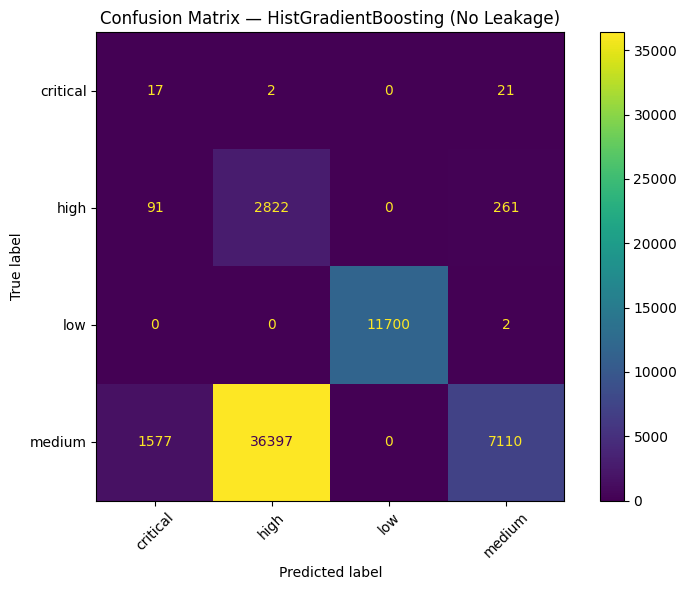

In [35]:
labels = sorted(y.unique())

cm_hgb = confusion_matrix(y_test, y_pred_hgb, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hgb, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix — HistGradientBoosting (No Leakage)")
plt.tight_layout()
plt.show()